# Notebook 2: PlanetScope training and evaluation

This notebook trains damage classifiers on the eight PlanetScope channels created by notebook 1: matching pre/post B, G, R and NIR patches at 3 m resolution.

The default `base_cnn` is a compact control architecture. Each block contains a 3 x 3 convolution, BatchNorm, ReLU and MaxPool(2), followed by global average pooling, dropout and one output logit. `siamese_cnn` remains selectable and uses a shared pre/post encoder.

## Spatial protocol

| role | latitude-quantile band | fitted component |
|---|---:|---|
| train | 0.55-1.00 | CNN weights |
| stack | 0.44-0.55 | XGBoost spatial stage |
| validation | 0.33-0.44 | early stopping, HPO, variant selection, threshold |
| test | 0.00-0.33 | one-time evaluation after selection |

Model checkpoints, HPO trials, and final variants are selected by validation ROC AUC. F1 is used only to fit the operating threshold after a candidate has been selected.

There are no buffer gaps. Planet has one imagery/assessment row per footprint. Spatial XGBoost features are calculated separately inside each role, so neighbours never cross a split boundary.


## 1. Colab setup


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q optuna xgboost pyarrow geopandas rasterio scikit-learn torchinfo


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 29.6 MB/s eta 0:00:00


In [3]:
import os
import sys
import json
import time
import hashlib
import importlib
import copy
import pickle
import warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchinfo import summary
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)

PROJECT_ROOT = '/content/drive/MyDrive/War-Damage-Detection'
PROJECT_DIR = os.path.join(PROJECT_ROOT, 'planet')
os.environ['PLANET_DAMAGE_BASE'] = PROJECT_DIR
os.environ['PLANET_EXPERIMENTS_DIR'] = os.path.join(PROJECT_DIR, 'experiments')
for path in (str(PROJECT_ROOT), str(PROJECT_DIR)):
    if path not in sys.path:
        sys.path.insert(0, path)

from planet import pipeline
importlib.reload(pipeline)
from planet.pipeline import (
    PLANET_BANDS, PlanetPairDataset, PLANET_MODEL_REGISTRY,
    inspect_dataset, load_dataset, footprint_latitude_reference, set_random_seed,
    latitude_quantile_spatial_split, spatial_split_metadata,
    estimate_shared_percentiles, build_planet_model,
    predict_planet_probs, neighbour_features,
    best_f1_threshold, binary_metrics, experiment_dirs,
    atomic_json_dump, atomic_torch_save,
)


### 1a. Experiment configuration


In [4]:
EVALUATE_ONLY = False

CONFIG = {
    'experiment_name': 'planet_exp001_base_cnn',
    'seed': 0,
    'selection_metric': 'roc_auc',
    'model': 'base_cnn',
    'bands': ['B', 'G', 'R', 'NIR'],

    # base_cnn and siamese_cnn share the same width/depth defaults so a
    # baseline (non-HPO) run compares architectures at matched capacity.
    # For siamese_cnn add head_dim/head_dropout
    'model_params': {},

    # Fixed latitude-quantile bands for scratch Planet experiments.
    'split': {
        'train': [0.55, 1.00],
        'stack': [0.44, 0.55],
        'val': [0.33, 0.44],
        'test': [0.00, 0.33],
    },
    'normalization': {
        'lower_percentile': 2.0,
        'upper_percentile': 98.0,
        'sample_patches': 20_000,
    },
    'augmentation': {
        'geometric': True,
        'brightness_jitter': 0.0,
    },
    'training': {
        'batch_size': 128,
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'max_epochs': 120,
        'patience': 10,
        'num_workers': 2,
        'predict_batch_size': 1024,
    },
    'stacking': {
        'enabled': True,
        'ks': [8, 32],
        'features': [
            'score_t0', 'k8_mean', 'k8_std',
            'k32_mean', 'k32_std',
        ],
        'n_estimators': 600,
        'max_depth': 4,
        'learning_rate': 0.05,
        'early_stopping_rounds': 40,
    },
    'hpo': {
        'enabled': True,
        'n_trials': 10,          # target total; increase to extend/resume
        'max_epochs': 25,
        'patience': 6,
        'train_subsample': 0.5,
        'timeout_minutes': None,  # resumable wall-clock budget
    },
}

if CONFIG['model'] not in PLANET_MODEL_REGISTRY:
    raise ValueError(f"model must be one of {sorted(PLANET_MODEL_REGISTRY)}")
def experiment_identity(cfg):
    """Configuration fields that define fitted models and selection.

    HPO trial count and timeout are budgets, not scientific settings. They
    may increase in place so an existing Optuna study can continue.
    """
    identity = copy.deepcopy(cfg)
    identity.get('hpo', {}).pop('n_trials', None)
    identity.get('hpo', {}).pop('timeout_minutes', None)
    return identity


set_random_seed(CONFIG['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT = experiment_dirs(CONFIG['experiment_name'])
CONFIG_PATH = OUT['root'] / 'config.json'
FINAL_SELECTION_PATH = OUT['metrics'] / 'final_selection.json'
FINAL_MARKER_PATH = OUT['metrics'] / 'final_test_complete.json'

if FINAL_MARKER_PATH.exists() and not EVALUATE_ONLY:
    EVALUATE_ONLY = True
    print(
        'The final test is already sealed. Switched to EVALUATE_ONLY so '
        'no fitted artifact can change.')

if CONFIG_PATH.exists():
    with CONFIG_PATH.open(encoding='utf-8') as handle:
        previous_config = json.load(handle)
    if experiment_identity(previous_config) != experiment_identity(CONFIG):
        raise RuntimeError(
            f'{OUT["root"]} contains a different scientific configuration. '
            'Only hpo.n_trials and hpo.timeout_minutes may change in place; '
            'otherwise choose a new experiment_name.')

    old_trials = int(previous_config.get('hpo', {}).get('n_trials', 0))
    new_trials = int(CONFIG.get('hpo', {}).get('n_trials', 0))
    if new_trials < old_trials:
        raise RuntimeError(
            f'Cannot reduce hpo.n_trials from {old_trials} to {new_trials} '
            'inside an existing experiment.')
    budget_changed = (
        old_trials != new_trials
        or previous_config.get('hpo', {}).get('timeout_minutes') !=
        CONFIG.get('hpo', {}).get('timeout_minutes'))
    if budget_changed and FINAL_SELECTION_PATH.exists():
        raise RuntimeError(
            'The final selection is already frozen. Use a new '
            'experiment_name before changing the HPO budget.')
    if previous_config != CONFIG:
        atomic_json_dump(CONFIG, CONFIG_PATH)
        print(
            f'Updated resumable HPO budget: n_trials '
            f'{old_trials} -> {new_trials}. Existing trials are retained.')
    else:
        print(
            'Compatible experiment found. Completed CNN runs will be '
            'reused and interrupted full-data training will resume.')
else:
    atomic_json_dump(CONFIG, CONFIG_PATH)
    print('Created new experiment configuration.')

print('device:', device)
print('experiment:', OUT['root'])
print('available models:', sorted(PLANET_MODEL_REGISTRY))
print('mode:', 'evaluate saved experiment' if EVALUATE_ONLY else 'train / resume')


Compatible experiment found. Completed CNN runs will be reused and interrupted full-data training will resume.
device: cuda
experiment: /content/drive/MyDrive/War-Damage-Detection/planet/experiments/planet_exp001_base_cnn
available models: ['base_cnn', 'siamese_cnn']
mode: train / resume


## 2. Load notebook 1 output and assign the spatial split


,role,n,fraction,damaged_n,damaged_fraction,damaged_percent
0,train,88732,46.98%,60044,67.67%,67.67%
1,stack,22275,11.79%,6657,29.89%,29.89%
2,val,22053,11.68%,14067,63.79%,63.79%
3,test,55814,29.55%,20807,37.28%,37.28%


,dataset
0,{'npz': '/content/drive/MyDrive/War-Damage-Det...


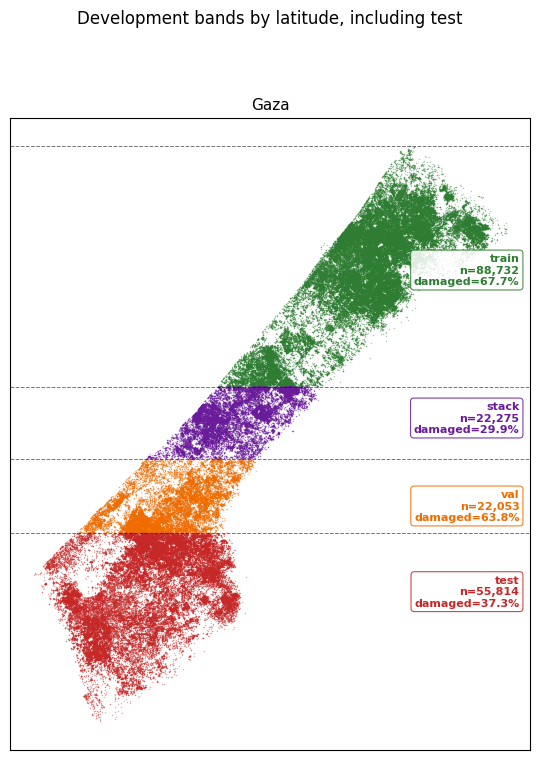

,city,split,buildings,fraction_pct,damaged,damaged_pct
0,Gaza,train,88732,47.0%,60044,67.7%
1,Gaza,stack,22275,11.8%,6657,29.9%
2,Gaza,val,22053,11.7%,14067,63.8%
3,Gaza,test,55814,29.6%,20807,37.3%


In [7]:
dataset_info = inspect_dataset(validate_alignment=True)
data = load_dataset(load_images=True)
X = data['X']
y = data['y']
table = data['gdf'].reset_index(drop=True)

if len(X) != len(y) or len(y) != len(table):
    raise RuntimeError(
        'NPZ/parquet row alignment changed after validation'
    )

if not np.array_equal(
    data['system_index'],
    table['system:index'].astype(str).to_numpy(),
):
    raise RuntimeError(
        'NPZ and parquet footprint IDs are not row-aligned'
    )

# Construct the bands in the order required by the split function.
split_roles = ('train', 'stack', 'val', 'test')
split_bands = {
    role: tuple(CONFIG['split'][role])
    for role in split_roles
}

split_reference = footprint_latitude_reference()
split = latitude_quantile_spatial_split(
    table,
    bands=split_bands,
    reference=split_reference,
)

split_meta = spatial_split_metadata(split)
atomic_json_dump(
    split_meta,
    OUT['metrics'] / 'spatial_split.json',
)

# Calculate prevalence for every split, including the test split.
# Kept as data for downstream use (e.g. class weighting); the per-split
# breakdown itself is shown once, by plot_planet_split_map below.
damage_prevalence = {}

for role in split_roles:
    idx = split[role]
    prevalence = float(y[idx].mean()) if len(idx) else np.nan
    damage_prevalence[role] = prevalence

display(pd.DataFrame({'dataset': [dataset_info]}))


def plot_planet_split_map(table, labels, split, split_meta, path=None):
    """Map Planet buildings by train/stack/validation/test role."""

    develop_roles = ('train', 'stack', 'val', 'test')

    colors = {
        'train': '#2E7D32',
        'stack': '#6A1B9A',
        'val': '#EF6C00',
        'test': '#C62828',
    }

    lat = table['lat'].to_numpy()
    lon = table['lon'].to_numpy()
    labels = np.asarray(labels)

    # Correct the longitude/latitude aspect ratio.
    longitude_scale = np.cos(np.radians(lat.mean()))
    aspect = 1 / longitude_scale

    fig, ax = plt.subplots(figsize=(5.5, 8.5))
    rows = []

    for role in develop_roles:
        idx = np.asarray(split[role], dtype=np.int64)

        if not len(idx):
            continue

        damaged_n = int(labels[idx].sum())
        damaged_pct = float(labels[idx].mean() * 100)

        ax.scatter(
            lon[idx],
            lat[idx],
            s=1.0,
            alpha=0.4,
            color=colors[role],
            label=role,
            linewidths=0,
        )

        rows.append({
            'city': 'Gaza',
            'split': role,
            'buildings': int(len(idx)),
            'fraction_pct': 100 * len(idx) / len(labels),
            'damaged': damaged_n,
            'damaged_pct': damaged_pct,
        })

        # Match the Sentinel map's inline split annotations.
        ax.text(
            0.98,
            lat[idx].mean(),
            (
                f'{role}\n'
                f'n={len(idx):,}\n'
                f'damaged={damaged_pct:.1f}%'
            ),
            transform=ax.get_yaxis_transform(),
            ha='right',
            va='center',
            fontsize=8,
            color=colors[role],
            fontweight='bold',
            bbox={
                'boxstyle': 'round,pad=0.3',
                'fc': 'white',
                'ec': colors[role],
                'alpha': 0.85,
                'lw': 0.8,
            },
        )

    # Draw each internal latitude boundary once.
    latitude_thresholds = split_meta['latitude_thresholds']
    boundaries = sorted({
        float(value)
        for role in develop_roles
        for value in latitude_thresholds[role]
        if lat.min() < float(value) < lat.max()
    })

    for boundary in boundaries:
        ax.axhline(
            boundary,
            color='black',
            linewidth=0.7,
            linestyle='--',
            alpha=0.55,
        )

    ax.set_title('Gaza', fontsize=11, pad=6)
    ax.set_aspect(aspect)
    ax.set_xticks([])
    ax.set_yticks([])

    fig.suptitle(
        'Development bands by latitude, including test',
        fontsize=12,
    )
    fig.tight_layout()

    if path:
        fig.savefig(
            path,
            dpi=150,
            bbox_inches='tight',
        )

    plt.show()

    summary = pd.DataFrame(rows).reset_index(drop=True)

    display(
        summary.style.format({
            'fraction_pct': '{:.1f}%',
            'damaged_pct': '{:.1f}%',
        })
    )

    return summary


split_summary = plot_planet_split_map(
    table=table,
    labels=y,
    split=split,
    split_meta=split_meta,
    path=OUT['figures'] / 'spatial_split.png',
)

## 3. Training-only normalization and data loaders


In [8]:
norm_cfg = CONFIG['normalization']
normalization_path = OUT['metrics'] / 'normalization.json'
if EVALUATE_ONLY:
    if not normalization_path.exists():
        raise FileNotFoundError(
            f'EVALUATE_ONLY requires saved normalization: {normalization_path}')
    with normalization_path.open(encoding='utf-8') as handle:
        normalization = json.load(handle)
    if list(normalization['bands']) != list(CONFIG['bands']):
        raise RuntimeError('Saved normalization bands do not match CONFIG')
    lo = np.asarray(normalization['lo'], dtype=np.float32)
    hi = np.asarray(normalization['hi'], dtype=np.float32)
    print('Loaded training-only normalization from the experiment.')
else:
    lo, hi, norm_rows = estimate_shared_percentiles(
        X, split['train'], bands=CONFIG['bands'],
        lower=norm_cfg['lower_percentile'],
        upper=norm_cfg['upper_percentile'],
        sample_patches=norm_cfg['sample_patches'], seed=CONFIG['seed'])
    normalization = {
        'bands': CONFIG['bands'], 'lo': lo.tolist(), 'hi': hi.tolist(),
        'sampled_training_rows': int(len(norm_rows)),
    }
    atomic_json_dump(normalization, normalization_path)
display(pd.DataFrame({'band': CONFIG['bands'], 'p02': lo, 'p98': hi}))

def make_loader(indices, batch_size, augment=False, shuffle=False):
    ds = PlanetPairDataset(
        X, y, indices, bands=CONFIG['bands'], lo=lo, hi=hi,
        augment=augment,
        brightness_jitter=(CONFIG['augmentation']['brightness_jitter'] if augment else 0.0))
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=CONFIG['training']['num_workers'],
        pin_memory=(device.type == 'cuda'), persistent_workers=False)

predict_loaders = {
    role: make_loader(split[role], CONFIG['training']['predict_batch_size'])
    for role in ('stack', 'val')
}


,band,p02,p98
0,B,655.0,2120.0
1,G,972.0,2750.0
2,R,997.0,3256.0
3,NIR,2000.0,4104.0


## 4. CNN training


In [9]:
def stratified_subsample(indices, fraction, seed):
    indices = np.asarray(indices, dtype=np.int64)
    if fraction >= 1:
        return indices
    rng = np.random.default_rng(seed)
    pieces = []
    for label in (0, 1):
        candidates = indices[y[indices] == label]
        count = max(1, int(round(fraction * len(candidates))))
        pieces.append(rng.choice(candidates, count, replace=False))
    return np.sort(np.concatenate(pieces))


def load_cnn(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = build_planet_model(
        checkpoint['model_name'], n_channels=2 * len(checkpoint['bands']),
        **checkpoint['model_params']).to(device)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()
    return model, checkpoint


def cpu_state_dict(model):
    return {
        name: value.detach().cpu().clone()
        for name, value in model.state_dict().items()
    }


def train_cnn(run_name, model_params, training_params, max_epochs=None,
              patience=None, trial=None, train_fraction=1.0,
              save=True, verbose=True, log_every=None):
    """Train, reuse, or resume one full-data CNN run.

    Completed runs are immutable and reused when their signature matches.
    Full-data baseline/HPO-winner runs save current model, optimizer, AMP,
    early-stopping, history, and RNG state after every epoch. Short Optuna
    trials use SQLite persistence and deliberately do not write CNN resume
    checkpoints.
    """
    trial_number = 0 if trial is None else trial.number + 1
    set_random_seed(CONFIG['seed'] + trial_number)
    train_idx = stratified_subsample(
        split['train'], train_fraction, CONFIG['seed'])
    batch_size = int(training_params['batch_size'])
    max_epochs = int(max_epochs or CONFIG['training']['max_epochs'])
    patience = int(patience or CONFIG['training']['patience'])
    model_params = dict(model_params)
    training_params = dict(training_params)

    signature = {
        'dataset_fingerprint': data['metadata']['preprocessing_fingerprint'],
        'model_name': CONFIG['model'],
        'model_params': model_params,
        'training_params': training_params,
        'bands': list(CONFIG['bands']),
        'augmentation': copy.deepcopy(CONFIG['augmentation']),
        'normalization': normalization,
        'split': split_meta,
        'train_rows': int(len(train_idx)),
        'train_indices_sha256': hashlib.sha256(
            np.asarray(train_idx, dtype='<i8').tobytes()).hexdigest(),
        'max_epochs': max_epochs,
        'patience': patience,
        'seed': int(CONFIG['seed'] + trial_number),
        'selection_metric': CONFIG['selection_metric'],
    }
    final_path = OUT['models'] / f'{run_name}.pt' if save else None
    resume_path = OUT['models'] / f'{run_name}_training.pt' if save else None

    if final_path is not None and final_path.exists():
        state = torch.load(final_path, map_location='cpu', weights_only=False)
        if state.get('complete') and state.get('signature') == signature:
            if verbose:
                print(
                    f"reused completed {run_name}: epoch "
                    f"{state['best_epoch']}, val_ROC_AUC={state['best_val_ROC_AUC']:.4f}")
            return {
                'name': run_name, 'checkpoint': str(final_path),
                'model_params': model_params,
                'training_params': training_params,
                'best_val_ROC_AUC': float(state['best_val_ROC_AUC']),
                'resumed': False, 'reused': True,
            }
        if verbose:
            print(f'completed checkpoint for {run_name} is incompatible; retraining')

    train_loader = make_loader(
        train_idx, batch_size,
        augment=CONFIG['augmentation']['geometric'], shuffle=True)
    val_loader = predict_loaders['val']
    model = build_planet_model(
        CONFIG['model'], n_channels=2 * len(CONFIG['bands']),
        **model_params).to(device)

    positives = int(y[train_idx].sum())
    negatives = len(train_idx) - positives
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(negatives / max(positives, 1), device=device))
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=training_params['learning_rate'],
        weight_decay=training_params['weight_decay'])
    use_amp = device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    start_epoch = 1
    best_auc, best_epoch, best_state = -np.inf, -1, None
    stale, history, resumed = 0, [], False
    if resume_path is not None and resume_path.exists():
        state = torch.load(resume_path, map_location='cpu', weights_only=False)
        if state.get('signature') == signature and not state.get('complete', False):
            model.load_state_dict(state['model_state'])
            optimizer.load_state_dict(state['optimizer_state'])
            if state.get('scaler_state'):
                scaler.load_state_dict(state['scaler_state'])
            start_epoch = int(state['completed_epoch']) + 1
            best_auc = float(state['best_val_ROC_AUC'])
            best_epoch = int(state['best_epoch'])
            best_state = state['best_model_state']
            stale = int(state['stale_epochs'])
            history = list(state['history'])
            torch.set_rng_state(state['torch_rng_state'])
            if use_amp and state.get('cuda_rng_state_all') is not None:
                torch.cuda.set_rng_state_all(state['cuda_rng_state_all'])
            resumed = True
            if verbose:
                print(
                    f'resuming {run_name} at epoch {start_epoch}; '
                    f'best epoch={best_epoch}, val_ROC_AUC={best_auc:.4f}')
        elif verbose:
            print(f'ignored incompatible resume checkpoint: {resume_path.name}')

    epoch_range = range(start_epoch, max_epochs + 1) if stale < patience else ()
    for epoch in epoch_range:
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += float(loss.detach()) * len(yb)

        val_scores, val_labels = predict_planet_probs(model, val_loader, device)
        val_auc = float(roc_auc_score(val_labels, val_scores))
        history.append({
            'epoch': epoch,
            'train_loss': running_loss / len(train_idx),
            'val_ROC_AUC': val_auc,
        })
        improved = best_state is None or val_auc > best_auc + 1e-6
        if improved:
            best_auc, best_epoch, stale = val_auc, epoch, 0
            best_state = cpu_state_dict(model)
        else:
            stale += 1

        periodic_log = (
            verbose or
            (log_every is not None and log_every > 0 and
             (epoch == start_epoch or epoch % log_every == 0 or
              epoch == max_epochs or stale >= patience)))
        if periodic_log:
            print(
                f'{run_name} epoch {epoch:03d} '
                f'loss={history[-1]["train_loss"]:.4f} '
                f'val_ROC_AUC={val_auc:.4f} best={best_auc:.4f}'
                + (' *' if improved else ''))

        if resume_path is not None:
            atomic_torch_save({
                'complete': False,
                'signature': signature,
                'completed_epoch': epoch,
                'model_state': cpu_state_dict(model),
                'optimizer_state': optimizer.state_dict(),
                'scaler_state': scaler.state_dict(),
                'best_model_state': best_state,
                'best_val_ROC_AUC': float(best_auc),
                'best_epoch': int(best_epoch),
                'stale_epochs': int(stale),
                'history': history,
                'torch_rng_state': torch.get_rng_state(),
                'cuda_rng_state_all': (
                    torch.cuda.get_rng_state_all() if use_amp else None),
            }, resume_path)

        if trial is not None:
            trial.report(val_auc, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if stale >= patience:
            if verbose:
                print(f'early stop; best epoch was {best_epoch}')
            break

    if best_state is None:
        raise RuntimeError(f'{run_name} has no best model state to finalize')
    model.load_state_dict(best_state)
    if final_path is not None:
        atomic_torch_save({
            'complete': True,
            'signature': signature,
            'run_name': run_name,
            'model_name': CONFIG['model'],
            'model_params': model_params,
            'training_params': training_params,
            'model_state': best_state,
            'bands': CONFIG['bands'],
            'lo': lo, 'hi': hi,
            'best_epoch': int(best_epoch),
            'best_val_ROC_AUC': float(best_auc),
            'history': history,
            'split': split_meta,
            'dataset_fingerprint': data['metadata']['preprocessing_fingerprint'],
        }, final_path)
        if verbose:
            print(
                f'saved completed {run_name}: best epoch={best_epoch}, '
                f'val_ROC_AUC={best_auc:.4f}')

    return {
        'name': run_name, 'checkpoint': str(final_path) if final_path else None,
        'model_params': model_params,
        'training_params': training_params,
        'best_val_ROC_AUC': float(best_auc),
        'resumed': resumed, 'reused': False,
    }


In [10]:
base_training = {
    key: CONFIG['training'][key]
    for key in ('batch_size', 'learning_rate', 'weight_decay')
}
RUNS = {}

# Show the configured baseline architecture before fitting any weights.
model_to_summarize = build_planet_model(
    CONFIG['model'], n_channels=2 * len(CONFIG['bands']),
    **CONFIG['model_params']).to(device)
input_shape = (
    1, 2 * len(CONFIG['bands']), int(X.shape[-2]), int(X.shape[-1]))

summary(
    model_to_summarize,
    input_size=input_shape,
    device=device,
    col_names=('input_size', 'output_size', 'num_params', 'trainable'),
    depth=5,
)
del model_to_summarize


In [11]:
if not EVALUATE_ONLY:
    RUNS['baseline'] = train_cnn(
        'baseline', CONFIG['model_params'], base_training)
else:
    for run_name in ('baseline', 'hpo'):
        checkpoint_path = OUT['models'] / f'{run_name}.pt'
        if not checkpoint_path.exists():
            continue
        _, checkpoint = load_cnn(checkpoint_path)
        RUNS[run_name] = {
            'name': run_name, 'checkpoint': str(checkpoint_path),
            'model_params': checkpoint['model_params'],
            'training_params': checkpoint['training_params'],
            'best_val_ROC_AUC': checkpoint['best_val_ROC_AUC'],
            'resumed': False, 'reused': True,
        }
    if not RUNS:
        raise RuntimeError('EVALUATE_ONLY found no completed CNN checkpoints')
    print('EVALUATE_ONLY loaded:', list(RUNS))


baseline epoch 001 loss=0.3558 val_ROC_AUC=0.7965 best=0.7965 *
baseline epoch 002 loss=0.3365 val_ROC_AUC=0.7979 best=0.7979 *
baseline epoch 003 loss=0.3308 val_ROC_AUC=0.7354 best=0.7979
baseline epoch 004 loss=0.3293 val_ROC_AUC=0.8146 best=0.8146 *
baseline epoch 005 loss=0.3242 val_ROC_AUC=0.8701 best=0.8701 *
baseline epoch 006 loss=0.3230 val_ROC_AUC=0.8651 best=0.8701
baseline epoch 007 loss=0.3233 val_ROC_AUC=0.8663 best=0.8701
baseline epoch 008 loss=0.3211 val_ROC_AUC=0.8311 best=0.8701
baseline epoch 009 loss=0.3208 val_ROC_AUC=0.8429 best=0.8701
baseline epoch 010 loss=0.3200 val_ROC_AUC=0.7911 best=0.8701
baseline epoch 011 loss=0.3188 val_ROC_AUC=0.8751 best=0.8751 *
baseline epoch 012 loss=0.3178 val_ROC_AUC=0.8047 best=0.8751
baseline epoch 013 loss=0.3176 val_ROC_AUC=0.7052 best=0.8751
baseline epoch 014 loss=0.3173 val_ROC_AUC=0.8602 best=0.8751
baseline epoch 015 loss=0.3172 val_ROC_AUC=0.8387 best=0.8751
baseline epoch 016 loss=0.3176 val_ROC_AUC=0.8647 best=0.875

## 5. Optional Optuna HPO

HPO uses only the train band for weight fitting and validation ROC AUC for pruning and selection. The winning settings are retrained on the full train band. Test is not loaded.


In [ ]:
def atomic_pickle_dump(value, path):
    path = Path(path)
    temporary = path.with_name(f'.{path.name}.part')
    with temporary.open('wb') as handle:
        pickle.dump(value, handle)
    os.replace(temporary, path)


def persist_hpo_state(study, _trial=None):
    trials_path = OUT['metrics'] / 'hpo_trials.csv'
    trials_temporary = trials_path.with_name(f'.{trials_path.name}.part')
    study.trials_dataframe().to_csv(trials_temporary, index=False)
    os.replace(trials_temporary, trials_path)
    complete = [trial for trial in study.trials if trial.state.name == 'COMPLETE']
    if complete:
        best = study.best_trial
        atomic_json_dump({
            'best_trial': best.number,
            'best_value': best.value,
            'selection_metric': 'validation_roc_auc',
            'best_params': best.params,
        }, OUT['metrics'] / 'hpo_best_params.json')
    atomic_pickle_dump(study.sampler, OUT['root'] / 'optuna_sampler.pkl')


study = None
if CONFIG['hpo']['enabled'] and not EVALUATE_ONLY:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Every CNN block ends with MaxPool2d(2). A P-pixel patch therefore
    # permits at most floor(log2(P)) blocks: 32 -> 16 -> 8 -> 4 -> 2 -> 1.
    patch_pixels = int(X.shape[-1])
    max_valid_depth = int(np.floor(np.log2(patch_pixels)))
    if max_valid_depth < 2:
        raise ValueError(f'Patch size {patch_pixels} is too small for this CNN')
    print(f'valid CNN depth range for {patch_pixels}x{patch_pixels} patches: 2..{max_valid_depth}')

    def objective(trial):
        model_params = {
            'width': trial.suggest_categorical('width', [8, 16, 32]),
            'depth': trial.suggest_int('depth', 2, max_valid_depth),
            'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        }
        if 2 ** model_params['depth'] > patch_pixels:
            raise optuna.TrialPruned(
                f"depth={model_params['depth']} is invalid for "
                f'{patch_pixels}x{patch_pixels} patches')
        if CONFIG['model'] == 'siamese_cnn':
            model_params.update({
                'head_dim': trial.suggest_categorical('head_dim', [64, 128, 256]),
                'head_dropout': trial.suggest_float('head_dropout', 0.1, 0.4),
            })
        training_params = {
            'batch_size': trial.suggest_categorical('batch_size', [64, 128, 256]),
            'learning_rate': trial.suggest_float(
                'learning_rate', 1e-4, 3e-3, log=True),
            'weight_decay': trial.suggest_float(
                'weight_decay', 1e-6, 1e-2, log=True),
        }
        run = train_cnn(
            f'hpo_trial_{trial.number}', model_params, training_params,
            max_epochs=CONFIG['hpo']['max_epochs'],
            patience=CONFIG['hpo']['patience'], trial=trial,
            train_fraction=CONFIG['hpo']['train_subsample'],
            save=False, verbose=False, log_every=5)
        print(
            f"trial {trial.number:03d} val_ROC_AUC={run['best_val_ROC_AUC']:.4f} "
            f'params={trial.params}')
        return run['best_val_ROC_AUC']

    sampler_path = OUT['root'] / 'optuna_sampler.pkl'
    sampler = optuna.samplers.TPESampler(seed=CONFIG['seed'])
    if sampler_path.exists():
        try:
            with sampler_path.open('rb') as handle:
                sampler = pickle.load(handle)
            print('restored Optuna sampler state')
        except Exception as exc:
            warnings.warn(f'could not restore Optuna sampler: {exc}')

    study = optuna.create_study(
        direction='maximize', study_name=CONFIG['experiment_name'],
        storage=f"sqlite:///{OUT['root'] / 'optuna.db'}",
        load_if_exists=True, sampler=sampler,
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5, n_warmup_steps=5))
    finished = sum(
        trial.state.name in ('COMPLETE', 'PRUNED')
        for trial in study.trials)
    remaining = max(int(CONFIG['hpo']['n_trials']) - finished, 0)
    if remaining and FINAL_SELECTION_PATH.exists():
        print('Final selection is frozen; no additional HPO trials will run.')
        remaining = 0
    if remaining:
        print(
            f'HPO target={CONFIG["hpo"]["n_trials"]}; '
            f'finished={finished}; running {remaining} additional trials')
        study.optimize(
            objective, n_trials=remaining,
            timeout=(CONFIG['hpo']['timeout_minutes'] or 0) * 60 or None,
            callbacks=[persist_hpo_state])
    else:
        print(
            f'HPO target already satisfied by {finished} '
            'completed/pruned trials; reusing study')
    persist_hpo_state(study)

    complete_trials = [
        trial for trial in study.trials if trial.state.name == 'COMPLETE']
    if not complete_trials:
        raise RuntimeError('The Optuna study has no completed trial.')

    trial_frame = study.trials_dataframe()
    parameter_columns = sorted(
        column for column in trial_frame if column.startswith('params_'))
    explored_rows = []
    completed_frame = trial_frame[trial_frame['state'] == 'COMPLETE']
    for column in parameter_columns:
        values = completed_frame[column].dropna()
        numeric = pd.to_numeric(values, errors='coerce')
        explored_rows.append({
            'parameter': column.removeprefix('params_'),
            'completed_trials': int(len(values)),
            'unique_values': int(values.nunique()),
            'minimum': float(numeric.min()) if numeric.notna().all() else np.nan,
            'maximum': float(numeric.max()) if numeric.notna().all() else np.nan,
            'values': ', '.join(map(str, sorted(values.unique(), key=str))),
        })
    HPO_EXPLORATION = pd.DataFrame(explored_rows)
    HPO_EXPLORATION.to_csv(
        OUT['metrics'] / 'hpo_parameter_exploration.csv', index=False)
    display(HPO_EXPLORATION)

    if len(complete_trials) >= 2:
        visualizations = {
            'optimization_history': optuna.visualization.plot_optimization_history,
            'parameter_slices': optuna.visualization.plot_slice,
            'parameter_importance': optuna.visualization.plot_param_importances,
        }
        for name, plot_function in visualizations.items():
            try:
                figure = plot_function(study)
                figure.write_html(
                    OUT['figures'] / f'hpo_{name}.html',
                    include_plotlyjs='cdn')
                figure.show()
            except Exception as exc:
                warnings.warn(f'Could not create HPO {name}: {exc}')

    best = study.best_params
    model_keys = {'width', 'depth', 'dropout', 'head_dim', 'head_dropout'}
    best_model_params = {k: v for k, v in best.items() if k in model_keys}
    best_training_params = {k: v for k, v in best.items() if k not in model_keys}
    print(
        f'retraining/reusing HPO winner trial {study.best_trial.number} '
        'on the full training band')
    RUNS['hpo'] = train_cnn(
        'hpo', best_model_params, best_training_params)
elif EVALUATE_ONLY:
    print('EVALUATE_ONLY: Optuna and all fitting skipped')
else:
    print('HPO disabled; the baseline remains the only CNN run.')

print(
    'runs to evaluate:',
    {name: round(run['best_val_ROC_AUC'], 4) for name, run in RUNS.items()})


valid CNN depth range for 32x32 patches: 2..5
HPO target=10; finished=0; running 10 additional trials
hpo_trial_0 epoch 001 loss=0.3385 val_ROC_AUC=0.8578 best=0.8578 *
hpo_trial_0 epoch 005 loss=0.2934 val_ROC_AUC=0.8993 best=0.8993 *
hpo_trial_0 epoch 010 loss=0.2796 val_ROC_AUC=0.9048 best=0.9048 *
hpo_trial_0 epoch 015 loss=0.2698 val_ROC_AUC=0.8783 best=0.9073


## 6. XGBoost spatial stacking and validation selection

Planet has one June pre/post image pair, so its XGBoost stage uses the spatial
subset of the compact feature design and no temporal predictors:

| feature | meaning |
|---|---|
| `score_t0` | CNN damage probability for the June image pair |
| `k8_mean` | mean `score_t0` of the eight nearest buildings |
| `k8_std` | standard deviation of those eight scores |
| `k32_mean` | mean `score_t0` of the 32 nearest buildings |
| `k32_std` | standard deviation of those 32 scores |

XGBoost receives no raw Planet bands, coordinates, neighbour distances or
individual neighbour scores. The CNN is scored on the separate stack band,
and neighbourhoods are constructed independently inside each spatial role.
Validation supplies XGBoost early stopping and final variant selection by ROC
AUC.


In [ ]:
def spatial_frame(role, scores):
    idx = split[role]
    return neighbour_features(
        split['xy'][idx], scores, ks=CONFIG['stacking']['ks'])

validation_rows = []
validation_predictions = pd.DataFrame({
    'system_index': data['system_index'][split['val']],
    'y': y[split['val']],
})

for run_name, run in RUNS.items():
    model, checkpoint = load_cnn(run['checkpoint'])
    val_scores, val_y = predict_planet_probs(
        model, predict_loaders['val'], device)

    threshold, best_f1 = best_f1_threshold(val_y, val_scores)
    raw_metrics = binary_metrics(val_y, val_scores, threshold)
    validation_rows.append({
        'run': run_name, 'variant': 'cnn', 'threshold': threshold,
        'validation_best_F1': best_f1, **raw_metrics,
        'checkpoint': run['checkpoint'], 'stacker': None})
    validation_predictions[f'{run_name}__cnn'] = val_scores

    if CONFIG['stacking']['enabled']:
        stack_scores, stack_y = predict_planet_probs(
            model, predict_loaders['stack'], device)
        X_stack = spatial_frame('stack', stack_scores)
        X_val = spatial_frame('val', val_scores)
        expected_columns = list(CONFIG['stacking']['features'])
        if (list(X_stack.columns) != expected_columns or
                list(X_val.columns) != expected_columns):
            raise RuntimeError(
                f'XGBoost feature schema mismatch: expected {expected_columns}, '
                f'got {list(X_stack.columns)}')
        stacker_path = OUT['models'] / f'{run_name}_xgb_spatial.joblib'
        stacker_meta_path = OUT['models'] / f'{run_name}_xgb_spatial.json'
        stacker_signature = {
            'format': 1,
            'run': run_name,
            'checkpoint': str(run['checkpoint']),
            'cnn_validation_ROC_AUC': float(run['best_val_ROC_AUC']),
            'stacking': copy.deepcopy(CONFIG['stacking']),
            'split': split_meta,
            'dataset_fingerprint': data['metadata']['preprocessing_fingerprint'],
        }
        reuse_stacker = False
        if stacker_path.exists() and stacker_meta_path.exists():
            with stacker_meta_path.open(encoding='utf-8') as handle:
                reuse_stacker = json.load(handle) == stacker_signature
        if reuse_stacker:
            stacker = joblib.load(stacker_path)
            print(f'reused spatial stacker for {run_name}')
        elif stacker_path.exists() and FINAL_MARKER_PATH.exists():
            # Completed experiments predate stacker metadata. Their config
            # and final result are immutable, so the saved stacker is safe
            # to migrate without fitting it again.
            stacker = joblib.load(stacker_path)
            atomic_json_dump(stacker_signature, stacker_meta_path)
            print(f'migrated saved stacker metadata for {run_name}')
        elif EVALUATE_ONLY:
            raise RuntimeError(
                f'EVALUATE_ONLY requires a compatible stacker for {run_name}')
        else:
            positives = int(stack_y.sum())
            negatives = len(stack_y) - positives
            scfg = CONFIG['stacking']
            stacker = XGBClassifier(
                n_estimators=scfg['n_estimators'], max_depth=scfg['max_depth'],
                learning_rate=scfg['learning_rate'], subsample=.9,
                colsample_bytree=.9, objective='binary:logistic',
                eval_metric='auc', tree_method='hist',
                scale_pos_weight=negatives / max(positives, 1),
                early_stopping_rounds=scfg['early_stopping_rounds'],
                random_state=CONFIG['seed'], n_jobs=-1)
            stacker.fit(
                X_stack, stack_y, eval_set=[(X_val, val_y)], verbose=False)
            temporary = stacker_path.with_suffix('.joblib.part')
            joblib.dump(stacker, temporary)
            os.replace(temporary, stacker_path)
            atomic_json_dump(stacker_signature, stacker_meta_path)
            print(f'fitted spatial stacker for {run_name}')
        val_xgb = stacker.predict_proba(X_val)[:, 1]

        threshold, best_f1 = best_f1_threshold(val_y, val_xgb)
        xgb_metrics = binary_metrics(val_y, val_xgb, threshold)
        validation_rows.append({
            'run': run_name, 'variant': 'xgb_spatial',
            'threshold': threshold, 'validation_best_F1': best_f1,
            **xgb_metrics, 'checkpoint': run['checkpoint'],
            'stacker': str(stacker_path)})
        validation_predictions[f'{run_name}__xgb_spatial'] = val_xgb

VALIDATION = pd.DataFrame(validation_rows).sort_values(
    'ROC_AUC', ascending=False).reset_index(drop=True)
validation_predictions.to_parquet(
    OUT['predictions'] / 'validation_predictions.parquet', index=False)
VALIDATION.to_csv(OUT['metrics'] / 'validation_candidates.csv', index=False)
display(VALIDATION[['run', 'variant', 'n', 'PR_AUC', 'ROC_AUC',
                    'F1', 'precision', 'recall', 'threshold']])

winner = VALIDATION.iloc[0].to_dict()
computed_selection = {
    'run': winner['run'], 'variant': winner['variant'],
    'validation_ROC_AUC': float(winner['ROC_AUC']),
    'validation_PR_AUC': float(winner['PR_AUC']),
    'threshold': float(winner['threshold']),
    'checkpoint': str(winner['checkpoint']),
    'stacker': (None if pd.isna(winner['stacker'])
                else str(winner['stacker'])),
    'selection_metric': 'validation_roc_auc',
    'split': split_meta,
    'selected_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
}
if FINAL_SELECTION_PATH.exists():
    with FINAL_SELECTION_PATH.open(encoding='utf-8') as handle:
        FINAL_SELECTION = json.load(handle)
    def artifact_name(value):
        # Artifact locations may change when an experiment is downloaded or
        # moved. The filename identifies the immutable artifact within models/.
        return None if value in (None, '', 'None') else Path(value).name

    same_choice = all(
        FINAL_SELECTION.get(key) == computed_selection.get(key)
        for key in ('run', 'variant', 'selection_metric', 'split'))
    same_artifacts = all(
        artifact_name(FINAL_SELECTION.get(key)) ==
        artifact_name(computed_selection.get(key))
        for key in ('checkpoint', 'stacker'))
    if not (same_choice and same_artifacts):
        raise RuntimeError(
            'The frozen model choice differs from the current validation '
            'winner. Use a new experiment_name instead of replacing it.')

    # The validation-fitted threshold is selected once and remains authoritative.
    print('Reused the frozen validation selection.')
else:
    FINAL_SELECTION = computed_selection
    atomic_json_dump(FINAL_SELECTION, FINAL_SELECTION_PATH)
    print('Saved the frozen validation selection.')
print(json.dumps(FINAL_SELECTION, indent=2))


### 6a. Validation comparison of every model variant

Candidates are ranked by validation ROC AUC. The comparison below uses each candidate's own validation-fitted threshold. `PR_AUC` and `ROC_AUC` are both threshold-free. The remaining classification metrics use that candidate-specific validation threshold. HPO rows are available when `CONFIG['hpo']['enabled'] = True`.


In [ ]:
variant_names = {
    ('baseline', 'cnn'): 'baseline',
    ('baseline', 'xgb_spatial'): 'xgb_spatial',
    ('hpo', 'cnn'): 'hpo',
    ('hpo', 'xgb_spatial'): 'hpo_xgb_spatial',
}
expected_variants = [
    'baseline', 'xgb_spatial', 'hpo', 'hpo_xgb_spatial'
]
comparison_columns = [
    'n', 'prevalence', 'threshold', 'PR_AUC', 'ROC_AUC',
    'precision', 'recall', 'F1', 'balanced_accuracy', 'specificity',
    'TN', 'FP', 'FN', 'TP',
]

comparison = VALIDATION.copy()
comparison['model_variant'] = [
    variant_names.get((run, variant), f'{run}_{variant}')
    for run, variant in zip(comparison['run'], comparison['variant'])
]
MODEL_COMPARISON = (
    comparison.set_index('model_variant')[comparison_columns]
    .reindex(expected_variants)
)
MODEL_COMPARISON.index.name = 'model_variant'
MODEL_COMPARISON.to_csv(
    OUT['metrics'] / 'validation_model_comparison.csv'
)

missing_variants = MODEL_COMPARISON.index[
    MODEL_COMPARISON['ROC_AUC'].isna()
].tolist()
if missing_variants:
    print(
        'Unavailable variants:', missing_variants,
        "Enable CONFIG['hpo']['enabled'] to include HPO comparisons."
    )

display(
    MODEL_COMPARISON.style
    .format({
        'n': '{:,.0f}', 'prevalence': '{:.4f}', 'threshold': '{:.4f}',
        'PR_AUC': '{:.4f}', 'ROC_AUC': '{:.4f}',
        'precision': '{:.4f}', 'recall': '{:.4f}', 'F1': '{:.4f}',
        'balanced_accuracy': '{:.4f}', 'specificity': '{:.4f}',
        'TN': '{:,.0f}', 'FP': '{:,.0f}', 'FN': '{:,.0f}', 'TP': '{:,.0f}',
    }, na_rep='not available')
    .background_gradient(
        subset=['PR_AUC', 'ROC_AUC', 'F1', 'balanced_accuracy'],
        cmap='YlGn'
    )
)

rate_metrics = [
    'PR_AUC', 'ROC_AUC', 'precision', 'recall',
    'F1', 'balanced_accuracy', 'specificity',
]
available_comparison = MODEL_COMPARISON.dropna(subset=['ROC_AUC'])
ax = available_comparison[rate_metrics].T.plot(
    kind='bar', figsize=(12, 6), width=.82
)
ax.set(
    ylabel='metric value', xlabel='', ylim=(0, 1.05),
    title='Planet validation comparison for all available model variants'
)
ax.grid(axis='y', alpha=.2)
ax.legend(title='model variant', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(
    OUT['figures'] / 'validation_model_comparison.png',
    dpi=180, bbox_inches='tight'
)
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
val_y = y[split['val']]
for row in VALIDATION.itertuples():
    scores = validation_predictions[f'{row.run}__{row.variant}'].to_numpy()
    precision, recall, _ = precision_recall_curve(val_y, scores)
    ax.plot(recall, precision, label=f'{row.run}/{row.variant} PR-AUC={row.PR_AUC:.3f}')
ax.axhline(val_y.mean(), color='0.5', linestyle='--', label='prevalence')
ax.set(xlabel='recall', ylabel='precision', title='Validation only')
ax.legend(fontsize=8)
fig.savefig(OUT['figures'] / 'validation_pr_curves.png', dpi=180, bbox_inches='tight')
plt.show()


## 7. One-shot sealed test evaluation

No alternative model, stacker or threshold is chosen from test results. The first complete evaluation saves predictions, metrics and figures before writing a completion marker. Later runs load those saved results without rescoring the test band.


In [ ]:
final_metrics_path = OUT['metrics'] / 'final_test_metrics.json'
final_predictions_path = (
    OUT['predictions'] / 'final_test_predictions.parquet')
with FINAL_SELECTION_PATH.open(encoding='utf-8') as handle:
    selection = json.load(handle)

if FINAL_MARKER_PATH.exists():
    with FINAL_MARKER_PATH.open(encoding='utf-8') as handle:
        marker = json.load(handle)
    if marker.get('selection') != selection:
        raise RuntimeError(
            'The final-test marker belongs to a different selection.')
    if not final_metrics_path.exists() or not final_predictions_path.exists():
        raise RuntimeError(
            'The final-test marker exists but a saved output is missing.')
    with final_metrics_path.open(encoding='utf-8') as handle:
        TEST_METRICS = json.load(handle)
    print('Final test already sealed; loaded the saved metrics.')
else:
    model, checkpoint = load_cnn(selection['checkpoint'])
    test_loader = make_loader(
        split['test'], CONFIG['training']['predict_batch_size'])
    test_cnn, test_y = predict_planet_probs(model, test_loader, device)
    if selection['variant'] == 'cnn':
        test_scores = test_cnn
    elif selection['variant'] == 'xgb_spatial':
        stacker = joblib.load(selection['stacker'])
        X_test = spatial_frame('test', test_cnn)
        test_scores = stacker.predict_proba(X_test)[:, 1]
    else:
        raise ValueError(
            f"Unknown frozen variant: {selection['variant']}")

    threshold = float(selection['threshold'])
    TEST_METRICS = binary_metrics(test_y, test_scores, threshold)
    predicted = (test_scores >= threshold).astype(np.int8)
    pd.DataFrame({
        'system_index': data['system_index'][split['test']],
        'y': test_y, 'cnn_score': test_cnn,
        'selected_score': test_scores, 'prediction': predicted,
    }).to_parquet(final_predictions_path, index=False)
    atomic_json_dump(TEST_METRICS, final_metrics_path)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    cm = confusion_matrix(test_y, predicted, labels=[0, 1])
    ConfusionMatrixDisplay(
        cm, display_labels=['intact', 'damaged']).plot(
        ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(
        f"Final test: {selection['run']} / {selection['variant']}")

    precision, recall, _ = precision_recall_curve(test_y, test_scores)
    axes[1].plot(
        recall, precision, label=f'PR-AUC={TEST_METRICS["PR_AUC"]:.3f}')
    axes[1].axhline(
        test_y.mean(), color='0.5', linestyle=':', label='prevalence')
    axes[1].scatter(
        TEST_METRICS['recall'], TEST_METRICS['precision'],
        color='tab:red', zorder=3,
        label=f'frozen threshold={threshold:.3f}')
    axes[1].set(
        xlabel='recall', ylabel='precision', title='Final test PR curve')
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(
        OUT['figures'] / 'final_test_diagnostics.png',
        dpi=180, bbox_inches='tight')
    plt.show()

    marker = {
        'selection': selection,
        'metrics': TEST_METRICS,
        'prediction_file': final_predictions_path.name,
        'completed_utc': time.strftime(
            '%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    }
    atomic_json_dump(marker, FINAL_MARKER_PATH)
    print(f'Sealed final-test outputs in {FINAL_MARKER_PATH}.')

display(pd.DataFrame([TEST_METRICS]))


## Done

The experiment folder now contains the fitted CNN checkpoint(s), optional Optuna study, XGBoost stacker(s), validation candidate table, frozen selection, and one-shot test outputs. the shared interactive-map notebook can consume `final_test_predictions.parquet` without reopening model selection.
